# Assignment 2 2AMM10 2025-2026

## Group: The Big Batch Theory
### Member 1: Haneul Choi (1773895)
### Member 2: Dimitar Dimitrov (1768441)
### Member 3: Wouter Feijen (1491032)

In [1]:
# Additional Imports
import platform
from torch_geometric.loader import DataLoader
from tqdm.auto import tqdm
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay

In [2]:
base_path = ""
SKIP_TRAINING = True

In [3]:
import torch
import json
import torch.nn as nn
import pandas as pd
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random
import numpy as np
import os

## Global Variables ##
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
DATA_DIR = os.path.join(base_path,"data") #"./data"
DROWSY_DATASET_DIR = Path(
    DATA_DIR, "drowsy_graph_dataset"
)  # Path to the drowsy dataset
OBJ_CLS_DATASET_DIR = Path(
    DATA_DIR, "bdd8cls_balanced_300_30"
)  # Path to the object classification dataset
DEVICE = (
    torch.device("cuda")
    if torch.cuda.is_available()
    else (
        torch.device("mps")
        if torch.backends.mps.is_available()
        else torch.device("cpu")
    )
)
print(f"Using device: {DEVICE}")

Using device: cuda


# Task 1

In [4]:
class DrowsyFaceGraphDataset(Dataset):
    def __init__(self, root, split="train"):
        self.root = Path(root)
        self.split = split

        data_path = self.root / f"{split}.pt"
        class_to_id_path = self.root / "class_to_id.json"
        id_to_class_path = self.root / "id_to_class.json"

        if not data_path.exists():
            raise FileNotFoundError(f"Could not find {data_path}")

        self.graphs = torch.load(data_path, weights_only=False)

        with open(class_to_id_path, "r") as f:
            self.class_to_id = json.load(f)

        with open(id_to_class_path, "r") as f:
            self.id_to_class = json.load(f)

    def __len__(self):
        return len(self.graphs)

    def __getitem__(self, idx):
        return self.graphs[idx]

In [5]:
# Visualization helper
def plot_face_graph(
    graph, ax=None, title=None, node_size=8, edge_alpha=0.20, edge_width=0.4
):
    """Plot one face graph using its 2D normalized landmark coordinates."""
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))

    coords = graph.x.cpu().numpy()  # Nodes of the Graph
    edge_index = graph.edge_index.cpu().numpy()  # Edges of the Graph

    xy = coords[:, :2]

    seen = set()
    for i, j in edge_index.T:
        a, b = int(i), int(j)
        key = tuple(sorted((a, b)))
        if key in seen:
            continue
        seen.add(key)
        ax.plot(
            [xy[a, 0], xy[b, 0]],
            [xy[a, 1], xy[b, 1]],
            linewidth=edge_width,
            alpha=edge_alpha,
        )

    ax.scatter(xy[:, 0], xy[:, 1], s=node_size)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.axis("off")

    if title is not None:
        ax.set_title(title)

    return ax

Load Datasets

In [6]:
train_dataset = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="train")
test_dataset = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="test")
class_to_id: dict = train_dataset.class_to_id
id_to_class: dict = train_dataset.id_to_class

# Number of samples in each dataset. Each sample represents a snapshot of a driver who is either awake or drowsy.
print(f"Number of samples (graphs) in train_dataset: {len(train_dataset)}") 
print(f"Number of samples (graphs) in test_dataset: {len(test_dataset)}\n")

# (60,3); 60 nodes representing a physical landmark on the driver's upper face
#         3 node features representing the 3D spatial coordinates normalized to [-1,1]
print(f"Node's shape: {train_dataset[0].x.shape}")

# (2,304); 304 edges connecting the 60 landmarks according to the Coordinate Formate (COO) for graphs meaning there are
#          2 rows, where the first contains the source nodes and the second contains the destination nodes for all 304 connections
print(f"Edge's shape: {train_dataset[0].edge_index.shape}")
# -> Together this is the 'upper-face mesh'
# -> upper face looking at eyelid closure, blink rate, eyebrow movement, ...; only focus on relevant info


# graph.y: target label; driver is awake (0), driver is drowsy (1)

Number of samples (graphs) in train_dataset: 400
Number of samples (graphs) in test_dataset: 100

Node's shape: torch.Size([60, 3])
Edge's shape: torch.Size([2, 304])


Visualize data

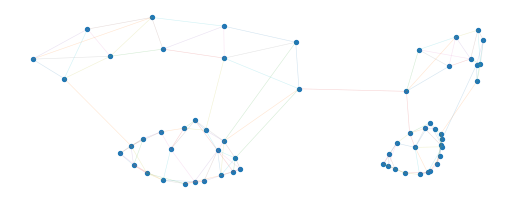

In [7]:
fig, ax = plt.subplots()
idx = random.randint(0, len(train_dataset) - 1)
graph = train_dataset[idx]
x, y = graph.x, graph.y
plot_face_graph(graph, ax);

# Understanding the samples
# 1) graph.x: (Num_nodes, 3) matrix. The coordinates (x1,x2,x3) of the facial landmarks, normalized to [-1,1]. Those are the node features of the graph.
# 2) graph.edge_index: (2, Num_edges) matrix. The edges of the graph, where each column (i,j) represents an edge from node i to node j.
# 3) graph.y: The label of the graph, where 0 means "alert" and 1 means "drowsy". This is the target variable we want to predict.
# 4) You can safely ignore the other 2 attributes of the graph (source_index and eye_openness) for this assignment.
# For completeness, eye_openness is a score in [0,1] that indicates how open the eyes are, and source_index is an index corresponding to the sample index with respect to the original dataset before graph construction.

#### Task) 1.1 Design a suitable neural-network architecture 

Class for Node Embeddings

In [8]:
class Node_to_emb(nn.Module):
    """Turn 3 dim input features (spatial coordinates) into a higher dimensional space
    before message passing to improve the learning capabilities."""

    def __init__(self, node_feat_dim=14, node_emb_dim=64):
        super().__init__()
        self.emb_dim = node_emb_dim
        self.node_dim = node_feat_dim
        self.emb = nn.Linear(self.node_dim, self.emb_dim)
        

    def forward(self, nodes):
        assert nodes.size(-1) == self.node_dim, 'wrong input dimension of node features!'
        out = self.emb(nodes)
        return out


Neural Message Passing Layer

In [9]:
class MpLayer(torch.nn.Module):
    def __init__(self, hidden_dim, activation=nn.ReLU()):
        super(MpLayer, self).__init__()

        # edge transfer function        
        self.edge_network = nn.Sequential(
            nn.Linear(2*hidden_dim, hidden_dim),
            activation,
            nn.Linear(hidden_dim, hidden_dim),
            activation
        )
        
        # node update function
        self.node_network = nn.Sequential(
            nn.Linear(2*hidden_dim, hidden_dim),
            activation,
            nn.Linear(hidden_dim, hidden_dim),
        )
        
    def forward(self, input_to_layer):
        node_tensor, edge_idx_tensor = input_to_layer
        edge_messages_input = torch.concat([node_tensor[edge_idx_tensor[0,:]], node_tensor[edge_idx_tensor[1,:]]], dim=-1) # shape (num_edges, 2*node_dim)
        edge_messages_output = self.edge_network(edge_messages_input) # shape (num_edges, hidden_dim)
                
        # aggregate edge messages
        node_agg_messages = torch.zeros(node_tensor.size(0), node_tensor.size(1)).to(node_tensor.device)
        node_agg_messages = node_agg_messages.scatter_add_(
            dim=0, index=edge_idx_tensor[1].unsqueeze(-1).expand(-1, node_tensor.size(1)), src=edge_messages_output
        )
               
        #put the aggregated messages through the node update network:
        node_out = self.node_network(torch.cat([node_tensor, node_agg_messages], dim=-1))

        return node_out, edge_idx_tensor

Message Passing GNN Class (Slightly Adapted from Practical 4.2)

In [10]:
class MpGNN(torch.nn.Module):
    def __init__(self, node_feat_dim, hidden_dim, activation=nn.ReLU(), num_layers=3, num_classes=2):
        super(MpGNN, self).__init__()

        # create node embeddings        
        self.node_to_emb = Node_to_emb(node_feat_dim, hidden_dim)

        # feature extraction layers; let nodes send messages across the entire graph
        self.forward_net = nn.Sequential(
            *[MpLayer(hidden_dim, activation) for i in range(num_layers)]
        )
        
        # classification head; map final complex features -> drowsy or awake
        # self.to_pred = nn.Sequential(nn.Linear(hidden_dim, num_classes), torch.nn.Softmax())
        self.to_pred = nn.Linear(hidden_dim,num_classes)

    def forward(self, x, edge_index, batch):
        x = self.node_to_emb(x)
        # print(x.size(), edge_index.size())
        input_model = (x, edge_index)
        output_model = self.forward_net(input_model)
        x,_ = output_model
        
        out = torch.zeros(max(batch)+1, x.size(1)).to(x.device)
        idx_aggregate_graph = batch.unsqueeze(-1).expand(-1, x.size(1))
    
        # graph read-out function: aggregate all node embeddings per graph in the batch
        out.scatter_add_(dim=0, index=idx_aggregate_graph, src=x)
        
        x = self.to_pred(out)
        return x

#### Task 1.2) Train the NN and visualize the training and test losses

Init Dataloaders

In [11]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Init params

In [12]:
# init hyperparams
hidden_dimension = 64
learning_rate = 0.0005
n_epochs = 50

# init model
model_t1 = MpGNN(
    node_feat_dim=3,     # 3D coordinates (x, y, z)
    hidden_dim=hidden_dimension, 
    num_layers=3,        # 3 message passing iterations
    num_classes=2        # Awake (0) or Drowsy (1)
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_t1 = model_t1.to(device)
optimizer = torch.optim.Adam(model_t1.parameters(), lr=learning_rate, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

Train Loop

In [13]:
def run_trainer(model, device, criterion, optimizer, train_loader, test_loader, n_epochs=50):
    train_losses = []
    test_losses = []

    epoch_bar = tqdm(range(n_epochs), desc="Training Progress")

    for epoch in epoch_bar:
        # --- TRAINING PHASE ---
        model.train()
        total_train_loss = 0

        for batch_data in train_loader:
            batch_data = batch_data.to(device)
            optimizer.zero_grad()
            
            # forward pass
            out = model(batch_data.x, batch_data.edge_index, batch_data.batch)
            loss = criterion(out, batch_data.y)
            
            # backward pass
            loss.backward()
            optimizer.step()
            
            total_train_loss += loss.item() * batch_data.num_graphs 
        
        # get avg loss and add to list
        avg_train_loss = total_train_loss / len(train_loader.dataset)
        train_losses.append(avg_train_loss)

        # --- TESTING PHASE ---
        model.eval()
        total_test_loss = 0
        with torch.no_grad():
            for batch_data in test_loader:
                batch_data = batch_data.to(device)
                
                out = model(batch_data.x, batch_data.edge_index, batch_data.batch)
                loss = criterion(out, batch_data.y)
                total_test_loss += loss.item() * batch_data.num_graphs

        avg_test_loss = total_test_loss / len(test_loader.dataset)
        test_losses.append(avg_test_loss)

        # print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}")
        epoch_bar.set_postfix({
            "Train Loss": f"{avg_train_loss:.4f}", 
            "Test Loss": f"{avg_test_loss:.4f}"
        })

    return train_losses, test_losses

# Helper to visualize losses
def plot_loss_history(train_losses, test_losses):
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Test Loss over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

Training the MpGNN

Using device: cuda
SKIP_TRAINING=True and weights found. Loading...
Model loaded successfully!


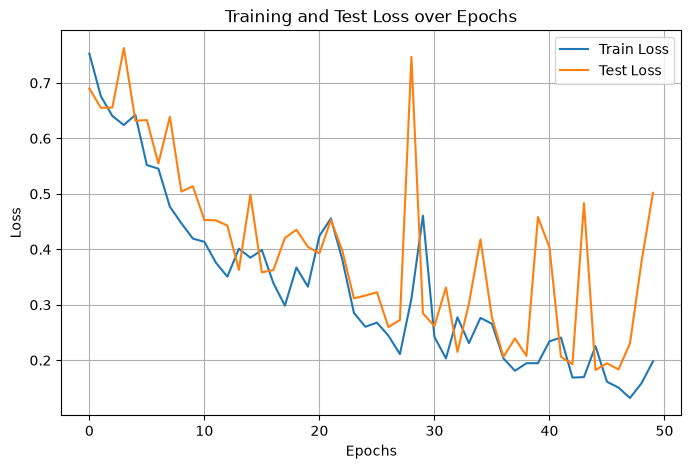

In [14]:
model_save_path = os.path.join(base_path, "drowsy_gnn_checkpoint.pth")
print(f'Using device: {DEVICE}')

if SKIP_TRAINING and os.path.exists(model_save_path):
    print("SKIP_TRAINING=True and weights found. Loading...")
    # load dictionary
    checkpoint = torch.load(model_save_path, map_location=device, weights_only=False)

    # load weights and set model to eval mode
    model_t1.load_state_dict(checkpoint["model_state_dict"])
    model_t1.eval()
    print("Model loaded successfully!")

    # Plot the loaded losses
    plot_loss_history(checkpoint['train_losses'], checkpoint['test_losses'])

else:
    if SKIP_TRAINING:
        print("SKIP_TRAINING=True but no weights found. Starting training...")
    else:
        print("SKIP_TRAINING=False. Starting training and overwriting saved weights...")
    
    # run training loop
    train_losses, test_losses = run_trainer(
        model=model_t1,
        device=device,
        criterion=criterion,
        optimizer=optimizer,
        train_loader=train_loader,
        test_loader=test_loader,
        n_epochs=50
    )

    # create checkpoint
    checkpoint = {
        'model_state_dict': model_t1.state_dict(),
        'train_losses': train_losses,
        'test_losses': test_losses
    }

    # save model weights
    torch.save(checkpoint, model_save_path)
    print(f"Training Complete. Model saved to {model_save_path}")
    
    # Plot the newly generated losses
    plot_loss_history(train_losses, test_losses)

#### Task 1.3, 1.4) Recall and Precision

Compute metrics with standard threshold

In [15]:
def evaluate_t1(model,loader,device,threshold=0.5):
    tp = 0
    fp = 0
    tn = 0
    fn = 0

    model.eval()
    with torch.no_grad():
        for batch_data in loader:
            batch_data = batch_data.to(device)
            out = model(batch_data.x, batch_data.edge_index, batch_data.batch)
            
            # get predictions from logits
            # pred_y = out.argmax(dim=1)
            prob_drowsy = torch.softmax(out,dim=1)[:, 1]
            pred_y = (prob_drowsy >= threshold).long()
            
            true_y = batch_data.y

            # compute tp,fp,fn
            tp += ((pred_y==1) & (true_y==1)).sum().item()
            fp += ((pred_y==1) & (true_y==0)).sum().item()
            tn += ((pred_y==0) & (true_y==0)).sum().item()
            fn += ((pred_y==0) & (true_y==1)).sum().item()

    accuracy = (tp+tn) / (tp+fp+tn+fn)
    recall = tp / (tp+fn)    # drowsy drivers correctly pred by model vs. total nr of drowsy drivers 
    precision = tp / (tp+fp) # drowsy drivers correctly pred by model vs. all drivers model pred as drowsy

    return accuracy, recall, precision

accuracy,recall,precision = evaluate_t1(model_t1,test_loader,device=DEVICE)

print(f"Test Metrics At Threshold=0.5")
print(f" > Test Accuracy:  {accuracy*100:.2f}%")
print(f" > Test Recall:    {recall:.2f}")
print(f" > Test Precision: {precision:.2f}")

Test Metrics At Threshold=0.5
 > Test Accuracy:  83.00%
 > Test Recall:    0.66
 > Test Precision: 1.00


Visualize Recall and Precision

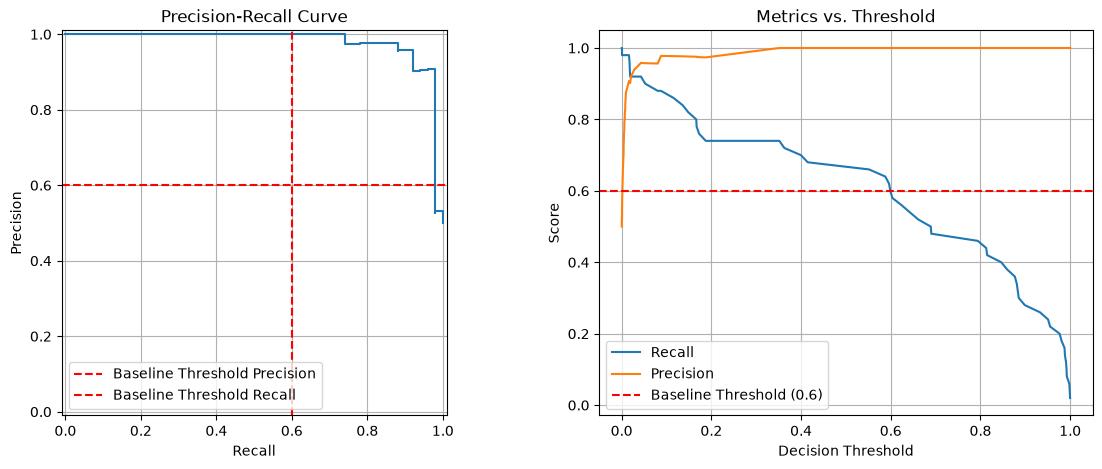

In [16]:
def plot_curves(model,loader,device):

    # retrieve probabilities and true targets from model
    y_prob = []
    y_true = []

    model.eval()
    with torch.no_grad():
        for batch_data in loader:
            batch_data = batch_data.to(device)

            # retrieve logits from predictions
            out = model(batch_data.x, batch_data.edge_index, batch_data.batch)
            probabilities = torch.softmax(out,dim=1)[:, 1]

            y_prob.extend(probabilities.cpu().numpy())
            y_true.extend(batch_data.y.cpu().numpy())

    # compute recall and precision scores
    precision_scores,recall_scores,thresholds_pr = precision_recall_curve(y_true,y_prob)

    # create figure
    fig, (ax1,ax2) = plt.subplots(1,2,figsize=(14,5))

    # plot PR-Curve
    display = PrecisionRecallDisplay(precision=precision_scores,recall=recall_scores)
    display.plot(ax=ax1)
    ax1.set_title("Precision-Recall Curve")
    ax1.grid(True)
    ax1.axhline(y=0.6, color='red', linestyle='--', label='Baseline Threshold Precision')
    ax1.axvline(x=0.6, color='red', linestyle='--', label='Baseline Threshold Recall')
    ax1.legend(loc='lower left')

    # plot threshold vs. metrics plot
    ax2.plot(thresholds_pr, recall_scores[:-1], label="Recall")
    ax2.plot(thresholds_pr, precision_scores[:-1], label="Precision")
    ax2.axhline(y=0.6, color='red', linestyle='--', label='Baseline Threshold (0.6)') 
    ax2.grid(True)
    ax2.set_xlabel("Decision Threshold")
    ax2.set_ylabel("Score")
    ax2.set_title("Metrics vs. Threshold")
    ax2.legend()
    ax2.grid(True)

    return precision_scores,recall_scores,thresholds_pr

precision_scores,recall_scores,thresholds_pr = plot_curves(model_t1,test_loader,device=DEVICE)

Finding the best threshold based on F2 score

In [17]:
beta = 2
f2_scores = (1 + beta**2) * (precision_scores[:-1] * recall_scores[:-1]) / \
            ((beta**2 * precision_scores[:-1]) + recall_scores[:-1] + 1e-8)

# find threshold maximizing F2 score
best_f2_idx = np.argmax(f2_scores)
optimal_threshold_f2 = thresholds_pr[best_f2_idx]

print(f"Optimal Threshold (F2 Score): {optimal_threshold_f2:.3f}")

Optimal Threshold (F2 Score): 0.016


Finding the best threshold based on a minimum recall of 98%

In [18]:
min_required_recall = 0.98

# fnd all indices where recall meets the safety constraint
valid_indices = np.where(recall_scores[:-1] >= min_required_recall)[0]

# find the index with the highest precision
best_idx = valid_indices[np.argmax(precision_scores[:-1][valid_indices])]

optimal_threshold = thresholds_pr[best_idx]
best_recall = recall_scores[best_idx]
best_precision = precision_scores[best_idx]

print(f"Optimal Threshold (Constraint): {optimal_threshold:.3f}")
print(f"    -> Recall:    {best_recall:.3f} \n    -> Precision: {best_precision:.3f}")

Optimal Threshold (Constraint): 0.016
    -> Recall:    0.980 
    -> Precision: 0.907


Final Metrics

In [22]:
final_accuracy,final_recall,final_precision = evaluate_t1(model_t1,test_loader,device=DEVICE,threshold=optimal_threshold)

print(f"Test Metrics At Threshold={optimal_threshold:.3f}")
print(f" > Test Accuracy: {final_accuracy*100:.2f}%")
print(f" > Test Recall: {final_recall:.2f}")
print(f" > Test Precision: {final_precision:.2f}")

Test Metrics At Threshold=0.016
 > Test Accuracy: 94.00%
 > Test Recall: 0.98
 > Test Precision: 0.91


# Task 2

In [20]:
class _BaseImageClassificationDataset(Dataset):
    """
    Base dataset for image classification datasets stored as:

        dataset_dir/
            class_to_id.json
            id_to_class.json
            train/
                000000.jpg
                ...
                labels.csv
                [metadata.csv]
            test/
                000000.jpg
                ...
                labels.csv
                [metadata.csv]
    """

    def __init__(
        self,
        dataset_dir,
        split="train",
        img_transform=None,
    ):
        super().__init__()
        self.dataset_dir = Path(dataset_dir)
        self.split = split
        self.img_transform = img_transform

        if self.split not in {"train", "test"}:
            raise ValueError(f"split must be 'train' or 'test', got: {self.split}")

        self.split_dir = self.dataset_dir / self.split
        self.labels_path = self.split_dir / "labels.csv"
        self.class_to_id_path = self.dataset_dir / "class_to_id.json"
        self.id_to_class_path = self.dataset_dir / "id_to_class.json"

        if not self.dataset_dir.exists():
            raise FileNotFoundError(f"Dataset directory not found: {self.dataset_dir}")
        if not self.split_dir.exists():
            raise FileNotFoundError(f"Split directory not found: {self.split_dir}")
        if not self.labels_path.exists():
            raise FileNotFoundError(f"labels.csv not found: {self.labels_path}")
        if not self.class_to_id_path.exists():
            raise FileNotFoundError(
                f"class_to_id.json not found: {self.class_to_id_path}"
            )
        if not self.id_to_class_path.exists():
            raise FileNotFoundError(
                f"id_to_class.json not found: {self.id_to_class_path}"
            )

        with open(self.class_to_id_path, "r") as fp:
            self.class_to_id = json.load(fp)

        with open(self.id_to_class_path, "r") as fp:
            self.id_to_class = json.load(fp)

        # Normalize keys for convenience
        self.id_to_class = {int(k): v for k, v in self.id_to_class.items()}
        self.num_classes = len(self.class_to_id)
        self.classes = [self.id_to_class[i] for i in range(self.num_classes)]

        self.labels = (
            pd.read_csv(self.labels_path, header=None).iloc[:, 0].astype(int).tolist()
        )

        self.img_paths = sorted(
            [
                p
                for p in self.split_dir.iterdir()
                if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
            ],
            key=lambda p: p.name,
        )

        if len(self.img_paths) != len(self.labels):
            raise ValueError(
                f"Mismatch between number of images ({len(self.img_paths)}) and "
                f"labels ({len(self.labels)}) in split '{self.split}'."
            )

    def __len__(self):
        return len(self.labels)

    def _load_image(self, img_path):
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.img_transform is not None:
                img = self.img_transform(img)
            return img

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        image = self._load_image(img_path)
        label = self.labels[idx]

        return image, label


class BDDObjectClassificationDataset(_BaseImageClassificationDataset):
    """
    Dataset for the cropped-object classification dataset.

    Returns:
        image, label
    or:
        image, label, metadata   (if return_metadata=True)

    Notes:
        - img_transform defaults to None.
        - The user is responsible for resizing / tensor conversion.
    """

    pass


class PatchShuffle:
    def __init__(self, patch_size=8):
        self.p = patch_size

    def __call__(self, img):
        # Input: [C, H, W]
        c, h, w = img.shape
        p = self.p

        # 1. Unfold image into patches [C, H/p, W/p, p, p]
        patches = img.unfold(1, p, p).unfold(2, p, p)
        num_h = h // p
        num_w = w // p

        # 2. Reshape to [num_patches, C, p, p]
        patches = patches.contiguous().view(c, -1, p, p).permute(1, 0, 2, 3)

        # 3. Shuffle the patches along the first dimension
        idx = torch.randperm(patches.size(0))
        patches = patches[idx]

        # 4. Reshape back to original image dimensions
        # We need to rearrange from [num_h*num_w, C, p, p] back to [C, H, W]
        patches = patches.view(num_h, num_w, c, p, p).permute(2, 0, 3, 1, 4)
        shuffled_img = patches.contiguous().view(c, h, w)

        return shuffled_img

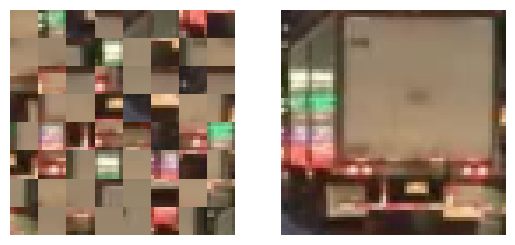

In [23]:
train_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="train",
    img_transform=None,  # Fill train image transforms
)

test_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=None,  # Fill test image transforms
)

### See how Patch Shuffle affects an image: CODE MEANT FOR ILLUSTRATION ###
from torchvision.transforms import Compose, ToTensor, Resize
from torchvision.transforms import functional as vf
import matplotlib.pyplot as plt

vis_dataset_noisy = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor(), PatchShuffle(patch_size=8)]),
)
vis_dataset_clean = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor()]),
)
fig, ax = plt.subplots(1, 2)
img_noisy, label = vis_dataset_noisy[16]
img_clean, label = vis_dataset_clean[16]
ax[0].imshow(vf.to_pil_image(img_noisy))
ax[1].imshow(vf.to_pil_image(img_clean))
for a in ax:
    a.set_xticks([])
    a.set_yticks([])
    a.set_frame_on(False)
### See how Patch Shuffle affects an image: CODE MEANT FOR ILLUSTRATION ###

In [25]:
import torch
from torch.utils.data import DataLoader
from torchvision.transforms import Compose, ToTensor, Resize, Normalize
import matplotlib.pyplot as plt
import numpy as np
import random

In [28]:
# Step 1: Create datasets and dataloaders
IMG_SIZE = 64
PATCH_SIZE = 8
BATCH_SIZE = 64

# clean transformation
clean_transform = Compose([
    Resize((IMG_SIZE, IMG_SIZE)),
    ToTensor(),
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# noisy transformation
noisy_transform = Compose([
    Resize((IMG_SIZE, IMG_SIZE)),
    ToTensor(),
    PatchShuffle(patch_size=PATCH_SIZE),
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Create datasets

train_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="train",
    img_transform=clean_transform
)

test_dataset_clean = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=clean_transform
)

test_dataset_noisy = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=noisy_transform
)

# Create dataloaders

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

test_loader_clean = DataLoader(
    test_dataset_clean,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader_noisy = DataLoader(
    test_dataset_noisy,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

# dataset statistics
num_classes = train_dataset.num_classes
class_names = train_dataset.classes

print("Classes:", class_names)
print("Number of train samples:", len(train_dataset))
print("Number of clean test samples:", len(test_dataset_clean))
print("Number of noisy test samples:", len(test_dataset_noisy))

Classes: ['person', 'rider', 'car', 'truck', 'bus', 'bike', 'traffic light', 'traffic sign']
Number of train samples: 2400
Number of clean test samples: 240
Number of noisy test samples: 240


In [29]:
# Step 2: Create Patch-invariant ViT without positional encodings

# First Part of the model: Patch Embedding
class PatchEmbedding(nn.Module):
    """Convert an image into patch embeddings."""

    def __init__(
        self,
        img_size,
        patch_size,
        in_channels,
        embed_dim
    ):

        super().__init__()

        if img_size % patch_size != 0:
            raise ValueError("img_size must be divisible by patch_size")

        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        self.proj = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size,
        )

    def forward(self, x):
        patch_grid = self.proj(x)
        patch_tokens = patch_grid.flatten(2).transpose(1, 2)
        return patch_tokens

# Second Part of the model: Embedding layers without positional encodings
class EmbeddingLayers(nn.Module):
    """Process patch embeddings without adding positional embeddings."""

    def __init__(
        self,
        embed_dim,
        depth,
        num_heads,
        mlp_ratio,
        dropout,
    ):
        
        super().__init__()

        if embed_dim % num_heads != 0:
            raise ValueError("embed_dim must be divisible by num_heads")

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=depth,
            enable_nested_tensor=False,
        )
        
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, patch_tokens):
        cls_tokens = self.cls_token.expand(patch_tokens.shape[0], -1, -1)
        tokens = torch.cat([cls_tokens, patch_tokens], dim=1)
        encoded_tokens = self.transformer(tokens)
        image_embedding = self.norm(encoded_tokens[:, 0])
        return image_embedding

# Third Part of the model: MLP head for classification
class MLPHead(nn.Module):
    """Classify the image-level embedding."""

    def __init__(
        self,
        embed_dim,
        num_classes,
        dropout
    ):
        
        super().__init__()

        self.layers = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, num_classes),
        )

    def forward(self, image_embedding):
        return self.layers(image_embedding)

# Final ViT model combining all three parts
class PatchInvariantViT(nn.Module):
    """ViT architecture without positional encodings."""

    def __init__(
        self,
        img_size,
        patch_size,
        in_channels,
        num_classes,
        embed_dim,
        depth,
        num_heads,
        mlp_ratio,
        dropout,
    ):
        super().__init__()
        self.patch_embedding = PatchEmbedding(
            img_size=img_size,
            patch_size=patch_size,
            in_channels=in_channels,
            embed_dim=embed_dim,
        )
        self.embedding_layers = EmbeddingLayers(
            embed_dim=embed_dim,
            depth=depth,
            num_heads=num_heads,
            mlp_ratio=mlp_ratio,
            dropout=dropout,
        )
        self.mlp_head = MLPHead(
            embed_dim=embed_dim,
            num_classes=num_classes,
            dropout=dropout,
        )

    def forward(self, x):
        patch_tokens = self.patch_embedding(x)
        image_embedding = self.embedding_layers(patch_tokens)
        return self.mlp_head(image_embedding)


In [30]:
# Step 3: Create Trainer class for the training loop

# Visualization function for loss curves
def plot_loss_history(train_losses, clean_test_losses, noisy_test_losses):
    n_epochs = len(train_losses)
    epochs = range(1, n_epochs + 1)

    plt.figure(figsize=(10, 5))

    # Train loss
    plt.plot(
        epochs,
        train_losses,
        label="Train Loss",
        color="tab:blue",
        linewidth=2,
    )

    # Clean test loss
    plt.plot(
        epochs,
        clean_test_losses,
        label="Clean Test Loss",
        color="tab:green",
        linewidth=5,
        alpha=0.45,
        zorder=2,
    )

    # Noisy test loss
    plt.plot(
        epochs,
        noisy_test_losses,
        label="Noisy Test Loss",
        color="tab:red",
        linestyle="--",
        marker="o",
        markersize=4,
        linewidth=2,
        zorder=3,
    )

    plt.title("Loss History per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

class Trainer:
    """Trainer class for training the model."""

    def __init__(
        self,
        model: nn.Module,
        device: torch.device,
        criterion: nn.Module,
        optimizer: torch.optim.Optimizer,
        train_DataLoader: torch.utils.data.DataLoader,
        clean_test_DataLoader: torch.utils.data.DataLoader,
        noisy_test_DataLoader: torch.utils.data.DataLoader,
        n_epochs: int,
    ):
        
        self.model = model
        self.device = device
        self.criterion = criterion
        self.optimizer = optimizer
        self.train_DataLoader = train_DataLoader
        self.clean_test_DataLoader = clean_test_DataLoader
        self.noisy_test_DataLoader = noisy_test_DataLoader
        self.n_epochs = n_epochs

    def _run_test_epoch(self, dataloader, description):
        """Run a test epoch and return the average loss."""

        self.model.eval()
        test_losses = []

        test_bar = tqdm(
            enumerate(dataloader),
            total=len(dataloader),
            desc=description,
            leave=True,
            dynamic_ncols=True,
        )

        for batch_idx, batch in test_bar:
            x, y = batch
            inputs = x.to(self.device)
            targets = y.to(self.device)

            with torch.no_grad():
                outputs = self.model(inputs)
                loss = self.criterion(outputs, targets)

            loss_value = loss.item()
            test_losses.append(loss_value)
            test_bar.set_postfix(
                {
                    "batch": f"{batch_idx + 1}/{len(dataloader)}",
                    "loss": f"{loss_value:.4f}",
                    "avg_loss": f"{np.mean(test_losses):.4f}",
                }
            )

        return np.mean(test_losses)

    def run_trainer(self):
        """Run the training loop for our model, keeping track of train, clean test, and noisy test losses per epoch."""

        train_losses_per_epoch = []
        clean_test_losses_per_epoch = []
        noisy_test_losses_per_epoch = []

        for epoch in range(self.n_epochs):
            self.model.train()
            train_losses = []

            train_bar = tqdm(
                enumerate(self.train_DataLoader),
                total=len(self.train_DataLoader),
                desc=f"Training epoch {epoch + 1}/{self.n_epochs}",
                leave=True,
                dynamic_ncols=True,
            )

            for batch_idx, batch in train_bar:
                x, y = batch
                inputs = x.to(self.device)
                targets = y.to(self.device)

                self.optimizer.zero_grad()
                outputs = self.model(inputs)
                loss = self.criterion(outputs, targets)

                loss.backward()
                self.optimizer.step()

                loss_value = loss.item()
                train_losses.append(loss_value)

                train_bar.set_postfix(
                    {
                        "batch": f"{batch_idx + 1}/{len(self.train_DataLoader)}",
                        "loss": f"{loss_value:.4f}",
                        "avg_loss": f"{np.mean(train_losses):.4f}",
                    }
                )

            # Compute average losses for the epoch (training)
            train_loss_epoch = np.mean(train_losses)

            # Compute average losses for the epoch (clean and noisy test)
            clean_test_loss_epoch = self._run_test_epoch(
                self.clean_test_DataLoader,
                description=f"Clean test epoch {epoch + 1}/{self.n_epochs}",
            )

            noisy_test_loss_epoch = self._run_test_epoch(
                self.noisy_test_DataLoader,
                description=f"Noisy test epoch {epoch + 1}/{self.n_epochs}",
            )

            train_losses_per_epoch.append(train_loss_epoch)
            clean_test_losses_per_epoch.append(clean_test_loss_epoch)
            noisy_test_losses_per_epoch.append(noisy_test_loss_epoch)

            print(
                f"Epoch: {epoch + 1}/{self.n_epochs}| "
                f"Train Loss: {train_loss_epoch:.4f}| "
                f"Clean Test Loss: {clean_test_loss_epoch:.4f}| "
                f"Noisy Test Loss: {noisy_test_loss_epoch:.4f}"
            )

        plot_loss_history(
            train_losses_per_epoch,
            clean_test_losses_per_epoch,
            noisy_test_losses_per_epoch,
        )

        return train_losses_per_epoch, clean_test_losses_per_epoch, noisy_test_losses_per_epoch

In [33]:
def set_seed(seed=42):
    """Seed for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

set_seed(42)

Using device: cuda
SKIP_TRAINING=True but no weights found. Starting training...


Training epoch 1/20:   0%|          | 0/38 [00:00<?, ?it/s]

Clean test epoch 1/20:   0%|          | 0/4 [00:00<?, ?it/s]

Noisy test epoch 1/20:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch: 1/20| Train Loss: 2.0291| Clean Test Loss: 1.9480| Noisy Test Loss: 1.9480


...

Epoch: 19/20| Train Loss: 1.1658| Clean Test Loss: 1.6271| Noisy Test Loss: 1.6271


Training epoch 20/20:   0%|          | 0/38 [00:00<?, ?it/s]

Clean test epoch 20/20:   0%|          | 0/4 [00:00<?, ?it/s]

Noisy test epoch 20/20:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch: 20/20| Train Loss: 1.1137| Clean Test Loss: 1.6369| Noisy Test Loss: 1.6369


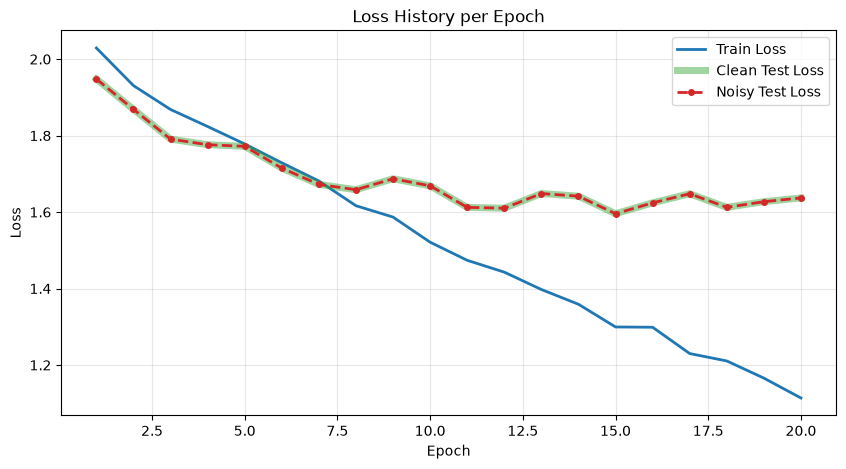

Training complete. Model saved to patch_invariant_vit_checkpoint.pth


In [46]:
# Step 4: Train or load the model

set_seed(42)  # Set seed for reproducibility

# Hyperparameters for the Patch-invariant ViT model
IMG_SIZE = 64
PATCH_SIZE = 8
IN_CHANNELS = 3
NUM_CLASSES = train_dataset.num_classes
EMBED_DIM = 128
DEPTH = 4
NUM_HEADS = 4
MLP_RATIO = 2.0
DROPOUT = 0.1

# Initialize the Patch-invariant ViT model
VIT_invariant_model = PatchInvariantViT(
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    in_channels=IN_CHANNELS,
    num_classes=NUM_CLASSES,
    embed_dim=EMBED_DIM,
    depth=DEPTH,
    num_heads=NUM_HEADS,
    mlp_ratio=MLP_RATIO,
    dropout=DROPOUT,
).to(DEVICE)

# Training hyperparameters
epochs = 20
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    VIT_invariant_model.parameters(),
    lr=2e-4,
    weight_decay=1e-4,
)

VIT_invariant_trainer = Trainer(
    model=VIT_invariant_model,
    device=DEVICE,
    criterion=criterion,
    optimizer=optimizer,
    train_DataLoader=train_loader,
    clean_test_DataLoader=test_loader_clean,
    noisy_test_DataLoader=test_loader_noisy,
    n_epochs=epochs,
)

vit_model_save_path = os.path.join(base_path, "patch_invariant_vit_checkpoint.pth")
print(f"Using device: {DEVICE}")

if SKIP_TRAINING and os.path.exists(vit_model_save_path):
    print("SKIP_TRAINING=True and weights found. Loading...")
    checkpoint = torch.load(vit_model_save_path, map_location=DEVICE, weights_only=False)

    VIT_invariant_model.load_state_dict(checkpoint["model_state_dict"])
    VIT_invariant_model.eval()
    print("Model loaded successfully!")

    train_losses = checkpoint["train_losses"]
    clean_test_losses = checkpoint["clean_test_losses"]
    noisy_test_losses = checkpoint["noisy_test_losses"]
    plot_loss_history(train_losses, clean_test_losses, noisy_test_losses)

else:
    if SKIP_TRAINING:
        print("SKIP_TRAINING=True but no weights found. Starting training...")
    else:
        print("SKIP_TRAINING=False. Starting training and overwriting saved weights...")

    train_losses, clean_test_losses, noisy_test_losses = VIT_invariant_trainer.run_trainer()

    checkpoint = {
        "model_state_dict": VIT_invariant_model.state_dict(),
        "train_losses": train_losses,
        "clean_test_losses": clean_test_losses,
        "noisy_test_losses": noisy_test_losses,
    }

    torch.save(checkpoint, vit_model_save_path)
    print(f"Training complete. Model saved to {vit_model_save_path}")


In [35]:
# Step 5: Calculate precision and recall metrics for clean and noisy test datasets

from sklearn.metrics import classification_report

def get_predictions(model, dataloader, device):
    """Get predictions and targets from the model for a given test dataloader."""

    model.eval()
    all_targets = []
    all_predictions = []

    for x, y in dataloader:
        inputs = x.to(device)
        targets = y.to(device)

        logits = model(inputs)
        predictions = logits.argmax(dim=1)

        all_targets.append(targets.cpu())
        all_predictions.append(predictions.cpu())

    targets = torch.cat(all_targets).numpy()
    predictions = torch.cat(all_predictions).numpy()
    return targets, predictions


def calculate_precision_recall_metrics(model, dataloader, class_names, device):
    """Calculate precision and recall metrics for a given model and test dataloader."""

    targets, predictions = get_predictions(model, dataloader, device)

    report_dict = classification_report(
        targets,
        predictions,
        target_names=class_names,
        output_dict=True,
    )

    report_table = pd.DataFrame(report_dict).transpose()
    per_class_table = report_table.loc[class_names, ["precision", "recall"]]
    aggregate_metrics = {
        "macro_precision": report_dict["macro avg"]["precision"],
        "macro_recall": report_dict["macro avg"]["recall"],
    }

    return per_class_table, aggregate_metrics

# Calculate precision and recall metrics for clean and noisy test datasets
clean_per_class_metrics, clean_aggregated_metrics = calculate_precision_recall_metrics(
    model=VIT_invariant_model,
    dataloader=test_loader_clean,
    class_names=class_names,
    device=DEVICE,
)

noisy_per_class_metrics, noisy_aggregated_metrics = calculate_precision_recall_metrics(
    model=VIT_invariant_model,
    dataloader=test_loader_noisy,
    class_names=class_names,
    device=DEVICE,
)


print("Clean test dataset precision and recall per class:")
display(clean_per_class_metrics)

print("Clean test dataset aggregated precision and recall:")
print(
    f"Aggregated macro precision: {clean_aggregated_metrics['macro_precision']:.3f}, "
    f"Aggregated macro recall: {clean_aggregated_metrics['macro_recall']:.3f}"
)

print("\n" + "=" * 50 + "\n")

print("Noisy test dataset precision and recall per class:")
display(noisy_per_class_metrics)

print(
    f"Aggregated macro precision: {noisy_aggregated_metrics['macro_precision']:.3f}, "
    f"Aggregated macro recall: {noisy_aggregated_metrics['macro_recall']:.3f}"
)


Clean test dataset precision and recall per class:


,precision,recall
person,0.416667,0.500000
rider,0.294118,0.166667
car,0.500000,0.433333
truck,0.360000,0.300000
bus,0.458333,0.366667
bike,0.342105,0.433333
traffic light,0.692308,0.600000
traffic sign,0.500000,0.800000


Clean test dataset aggregated precision and recall:
Aggregated macro precision: 0.445, Aggregated macro recall: 0.450


Noisy test dataset precision and recall per class:


,precision,recall
person,0.416667,0.500000
rider,0.294118,0.166667
car,0.500000,0.433333
truck,0.360000,0.300000
bus,0.458333,0.366667
bike,0.342105,0.433333
traffic light,0.692308,0.600000
traffic sign,0.500000,0.800000


Aggregated macro precision: 0.445, Aggregated macro recall: 0.450


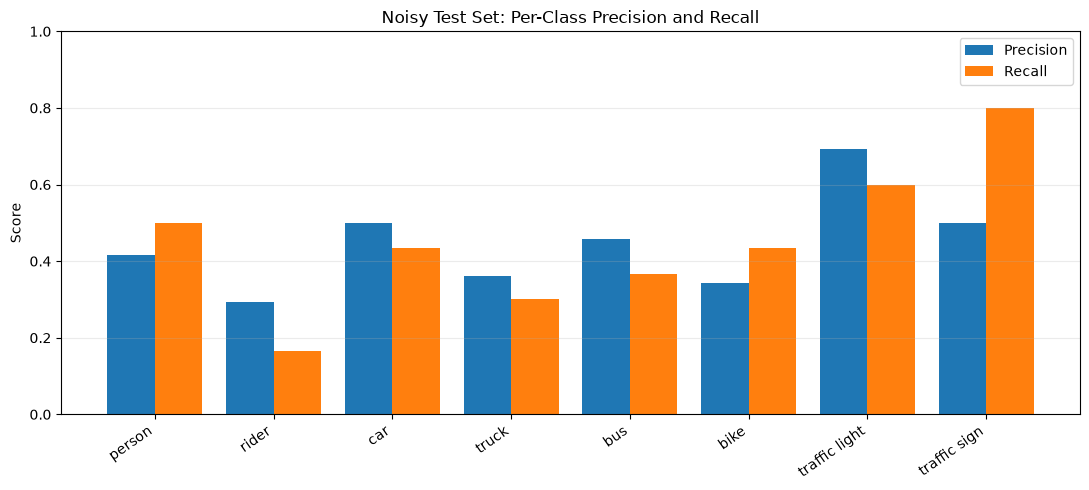

In [36]:
# Step 6: Visualize per-class precision and recall for noisy test datasets

x = np.arange(len(noisy_per_class_metrics))
bar_width = 0.4

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(
    x - bar_width / 2,
    noisy_per_class_metrics["precision"],
    width=bar_width,
    label="Precision",
)
ax.bar(
    x + bar_width / 2,
    noisy_per_class_metrics["recall"],
    width=bar_width,
    label="Recall",
)

ax.set_xticks(x)
ax.set_xticklabels(noisy_per_class_metrics.index, rotation=35, ha="right")
ax.set_ylim(0.0, 1.0)
ax.set_ylabel("Score")
ax.set_title("Noisy Test Set: Per-Class Precision and Recall")
ax.legend()
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()


## Task 3 

In [22]:
# This utility class is aimed to help you a bit with the linear probe classifier.
# You can choose whether to implement it or not!


class LinearProbeClassifier(nn.Module):
    """
    Frozen pretrained backbone + trainable linear classification head.

    TODO:
    - load a pretrained backbone,
    - remove/replace its original classification head (if any),
    - freeze the backbone parameters,
    - add a new trainable linear head for the BDD classes.
    """

    def __init__(self, backbone_arch: str, num_classes: int):
        super().__init__()
        self.backbone = None  # Here you can use a function that creates the backbone model based on the backbone_arch string (take a look here: https://docs.pytorch.org/vision/main/models.html)

        # TODO: Sometimes the pretrained backbone may already have a classification head (e.g. ResNet's fc layer, ViT's heads layer). In this case you might need to replace it with an Identity layer to get the features before the head.
        # The Identity layer is simply a placeholder for the Identity function, which returns its input unchanged.

        # TODO: freeze all pretrained backbone parameters. Freezing a parameter means that it will not be updated during gradient updates.

        # TODO: define the trainable linear classification head
        self.linear_head = None

    def forward(self, x: torch.Tensor):
        # The backbone should be used as a feature extractor.

        # Then the features from the backbone are passed through the linear head to get the final logits for classification.
        pass